In [94]:
import pandas as pd
import pickle
import numpy as np
import os
import xgboost as xgb
from tqdm import tqdm
from modules.manuscript_utils import calc_metrics

output_base = 'output/data' 
df_ML = pickle.load(open(f'{output_base}/df_ML.pkl', "rb"))
df_ML_train = pickle.load(open(f'{output_base}/df_ML_train.pkl', "rb"))
df_ML_test = pickle.load(open(f'{output_base}/df_ML_test.pkl', "rb"))
df_ML_unscaled = pickle.load(open(f'{output_base}/df_ML_unscaled.pkl', "rb"))
feature_names = pickle.load(open(f'{output_base}/feature_names.pkl', "rb"))
ML_feature_names = pickle.load(open(f'{output_base}/ML_feature_names.pkl', "rb"))

figure_path = 'output/figures'
if not os.path.exists(figure_path):
    os.makedirs(figure_path)

In [95]:

from collections import OrderedDict

feature_name_map = OrderedDict([
    ('max_force', 'Max Force'),
    ('force_variation_rate', 'Force Variation Rate'),
    ('avg_first_5', 'Average First 5 Samples'),
    ('avg_last_5', 'Average Last 5 Samples'),
    ('pk_sharp_max', 'Max Peak Sharpness'),
    ('pk_sharp_mean', 'Mean Peak Sharpness'),
    ('pk_sharp_min', 'Min Peak Sharpness'),
    ('skewness', 'Skewness'),
    ('kurtosis', 'Kurtosis'),
    ('total_press_duration', 'Press Duration'),
    ('pk_num', 'Peak Number'),
    ('pk_widths_max', 'Max Peak Width'),
    ('pk_widths_mean', 'Mean Peak Width'),
    ('pk_widths_min', 'Min Peak Width')
])

ordered_features = list(feature_name_map.keys())
ordered_features

['max_force',
 'force_variation_rate',
 'avg_first_5',
 'avg_last_5',
 'pk_sharp_max',
 'pk_sharp_mean',
 'pk_sharp_min',
 'skewness',
 'kurtosis',
 'total_press_duration',
 'pk_num',
 'pk_widths_max',
 'pk_widths_mean',
 'pk_widths_min']

# Univariate analysis

## Within-rat predictability

In [96]:
import numpy as np
import pandas as pd
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split

id_col = 'id'
label_col = 'label'

# Use ordered_features defined above; keep only existing columns
features_for_auc = [f for f in ordered_features if f in df_ML_train.columns]


per_rat_rows = []
for feat in tqdm(features_for_auc, desc="Processing features"):
    for rat_id, g in df_ML_train[[id_col, label_col, feat]].dropna().groupby(id_col):
        X = g[[feat]]
        y = g[label_col]

        X_train, X_test, y_train, y_test = train_test_split(
            X,
            y,
            test_size=0.2,
            random_state=42,
            stratify=y
        )

        model = xgb.XGBClassifier(
            tree_method="hist",
            random_state=42
        )
        model.fit(X_train, y_train)
        y_pred = model.predict_proba(X_test)[:, 1]

        auc = roc_auc_score(y_test, y_pred)
        per_rat_rows.append({
            'Feature': feat,
            'RatID': rat_id,
            'AUC': float(auc),
            'AUC_abs': float(max(auc, 1 - auc))
        })

df_within_rat_auc = pd.DataFrame(per_rat_rows)


Processing features: 100%|██████████| 14/14 [00:45<00:00,  3.26s/it]


In [97]:
# Summary table requested: AUC mean + SD across rats for each feature
summary = (
    df_within_rat_auc
    .groupby('Feature', as_index=False)
    .agg(
        N_rats=('AUC', 'count'),
        AUC_mean=('AUC', 'mean'),
        AUC_sd=('AUC', 'std')
    )
)

summary['Feature'] = summary['Feature'].map(feature_name_map).fillna(summary['Feature'])
summary = summary.sort_values('AUC_mean', ascending=False).reset_index(drop=True)

# Rounded display table
df_within_rat_auc_summary = summary.copy()
for c in ['AUC_mean', 'AUC_sd']:
    df_within_rat_auc_summary[c] = df_within_rat_auc_summary[c].round(3)

display(df_within_rat_auc_summary)

,Feature,N_rats,AUC_mean,AUC_sd
0,Press Duration,36,0.601,0.082
1,Max Peak Width,36,0.591,0.079
2,Peak Number,36,0.580,0.074
3,Mean Peak Width,36,0.568,0.053
4,Min Peak Sharpness,36,0.563,0.091
5,Max Force,36,0.560,0.068
6,Mean Peak Sharpness,36,0.555,0.095
7,Force Variation Rate,36,0.551,0.093
8,Average Last 5 Samples,36,0.545,0.085
9,Min Peak Width,36,0.545,0.046


## Across-rat stability

In [98]:
from sklearn.model_selection import GroupKFold, cross_val_score

# Across-rat descriptive stability uses only df_ML_train.
# The separate hold-out set is reserved for final evaluation and is not used here.
per_rat_groupkfold_rows = []

for feat in tqdm(features_for_auc, desc="5-fold across rats"):
    feature_df = df_ML_train[[id_col, label_col, feat]].dropna().copy()
    X = feature_df[[feat]]
    y = feature_df[label_col]
    groups = feature_df[id_col]

    cv = GroupKFold(n_splits=10)
    model = xgb.XGBClassifier(
        tree_method="hist",
        random_state=42
    )

    fold_aucs = cross_val_score(
        model,
        X,
        y,
        cv=cv,
        groups=groups,
        scoring="roc_auc"
    )

    for fold_idx, fold_auc in enumerate(fold_aucs, start=1):
        per_rat_groupkfold_rows.append({
            'Feature': feat,
            'Fold': fold_idx,
            'AUC': float(fold_auc)
        })

df_across_rat_groupkfold = pd.DataFrame(per_rat_groupkfold_rows)
df_across_rat_groupkfold_summary = (
    df_across_rat_groupkfold
    .groupby('Feature', as_index=False)
    .agg(
        N_folds=('AUC', 'count'),
        AUC_mean=('AUC', 'mean'),
        AUC_sd=('AUC', 'std')
    )
)

df_across_rat_groupkfold_summary['Feature'] = df_across_rat_groupkfold_summary['Feature'].map(feature_name_map).fillna(df_across_rat_groupkfold_summary['Feature'])
df_across_rat_groupkfold_summary = df_across_rat_groupkfold_summary.sort_values('AUC_mean', ascending=False).reset_index(drop=True)

for c in ['AUC_mean', 'AUC_sd']:
    df_across_rat_groupkfold_summary[c] = df_across_rat_groupkfold_summary[c].round(3)

display(df_across_rat_groupkfold_summary)

5-fold across rats: 100%|██████████| 14/14 [00:18<00:00,  1.34s/it]


,Feature,N_folds,AUC_mean,AUC_sd
0,Press Duration,10,0.597,0.044
1,Max Peak Width,10,0.579,0.049
2,Peak Number,10,0.569,0.038
3,Max Force,10,0.565,0.038
4,Mean Peak Width,10,0.557,0.048
5,Kurtosis,10,0.547,0.030
6,Force Variation Rate,10,0.544,0.035
7,Min Peak Sharpness,10,0.543,0.058
8,Min Peak Width,10,0.536,0.034
9,Skewness,10,0.530,0.034


## Combined plots

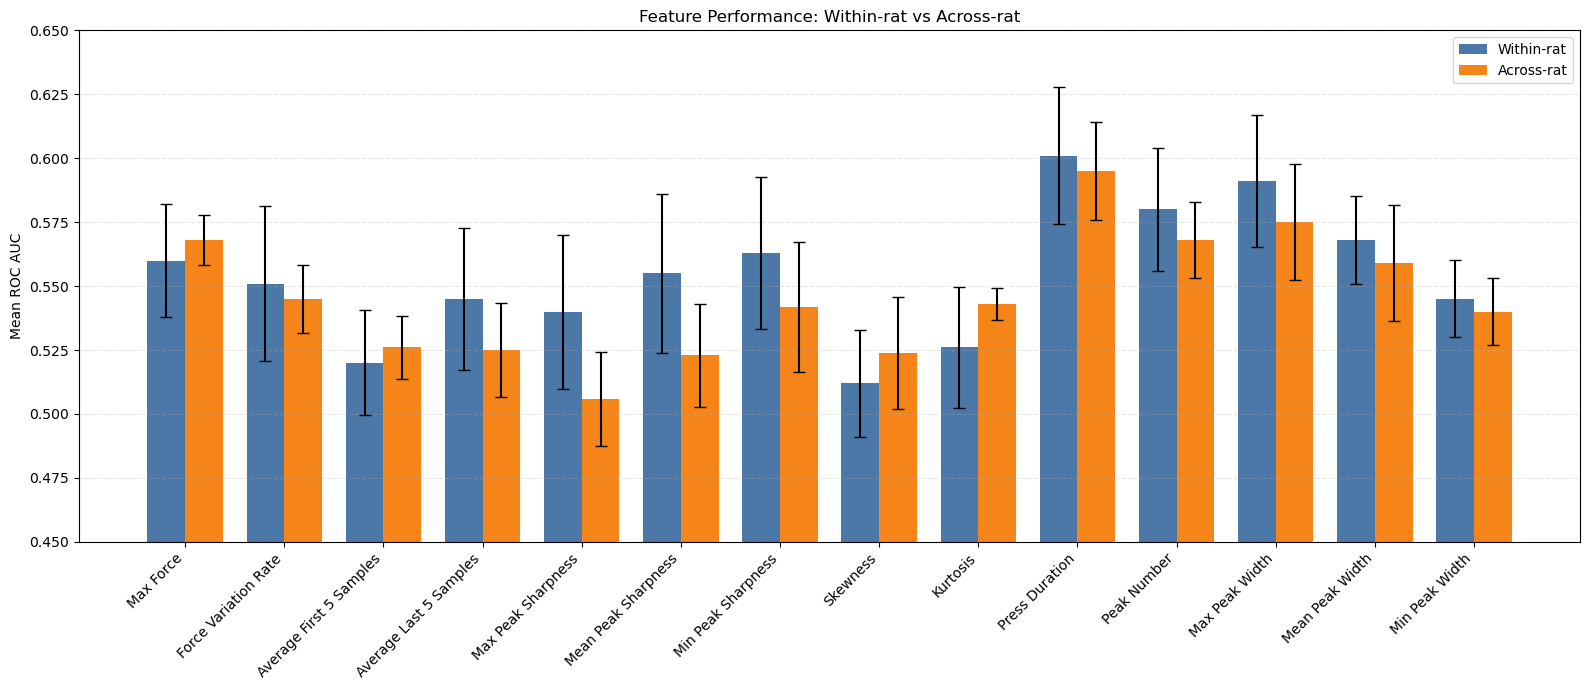

In [20]:
import matplotlib.pyplot as plt

within_plot = df_within_rat_auc_summary.copy()
within_plot['Dataset'] = 'Within-rat'
within_plot['N'] = within_plot['N_rats']

across_plot = df_across_rat_groupkfold_summary.copy()
across_plot['Dataset'] = 'Across-rat'
across_plot['N'] = across_plot['N_folds']

plot_df = pd.concat([within_plot, across_plot], ignore_index=True, sort=False)
plot_df['CI95'] = 1.96 * (plot_df['AUC_sd'] / np.sqrt(plot_df['N']))
plot_df['CI95'] = plot_df['CI95'].fillna(0)

feature_order = [
    feature_name_map[f]
    for f in ordered_features
    if feature_name_map[f] in plot_df['Feature'].values
]

within_vals = (
    plot_df[plot_df['Dataset'] == 'Within-rat']
    .set_index('Feature')
    .reindex(feature_order)
    .reset_index()
)
across_vals = (
    plot_df[plot_df['Dataset'] == 'Across-rat']
    .set_index('Feature')
    .reindex(feature_order)
    .reset_index()
)

x = np.arange(len(feature_order))
bar_width = 0.38

fig, ax = plt.subplots(figsize=(16, 7))
ax.bar(
    x - bar_width / 2,
    within_vals['AUC_mean'],
    bar_width,
    yerr=within_vals['CI95'],
    capsize=4,
    label='Within-rat',
    color='#4C78A8'
 )
ax.bar(
    x + bar_width / 2,
    across_vals['AUC_mean'],
    bar_width,
    yerr=across_vals['CI95'],
    capsize=4,
    label='Across-rat',
    color='#F58518'
 )

ax.set_xticks(x)
ax.set_xticklabels(feature_order, rotation=45, ha='right')
ax.set_ylabel('Mean ROC AUC')
ax.set_title('Feature Performance: Within-rat vs Across-rat')
ax.set_ylim(0.45, 0.65)
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

# GB

In [2]:
x_train = df_ML_train.loc[:, ML_feature_names]
y_train = df_ML_train.loc[:, 'label'].values
x_test = df_ML_test.loc[:, ML_feature_names]
y_test = df_ML_test.loc[:, 'label'].values


In [7]:
import xgboost as xgb

gb = xgb.XGBClassifier(
    max_depth=2,
    min_child_weight=8,
    subsample=0.9,
    colsample_bytree=1,
    reg_lambda=10,
    tree_method="hist",
    random_state=42
)


gb.fit(x_train, y_train)
y_pred = gb.predict_proba(x_test)[:, 1]
df_ML_test["gb_prob"] = y_pred
GB_metrics = calc_metrics(y_test, y_pred)
print(GB_metrics)


{'threshold': 0.244, 'f1_score': 0.572, 'recall': 0.777, 'precision': 0.453, 'auc': 0.64}


In [ ]:
# Will not be used in the manuscript
# feature importance
import matplotlib.pyplot as plt
importance = gb.feature_importances_
feature_importance_df = pd.DataFrame({
    'Feature': ML_feature_names,
    'Importance': importance
})

feature_importance_df['Feature'] = feature_importance_df['Feature'].map(feature_name_map).fillna(feature_importance_df['Feature'])
feature_importance_df = feature_importance_df.sort_values('Importance', ascending=False).reset_index(drop=True)
display(feature_importance_df)

,Feature,Importance
0,Press Duration,0.191175
1,Max Peak Width,0.175557
2,sex,0.173718
3,Average First 5 Samples,0.097732
4,Average Last 5 Samples,0.091412
5,Max Force,0.062549
6,Min Peak Width,0.051150
7,Kurtosis,0.036305
8,Mean Peak Width,0.035838
9,Min Peak Sharpness,0.034316


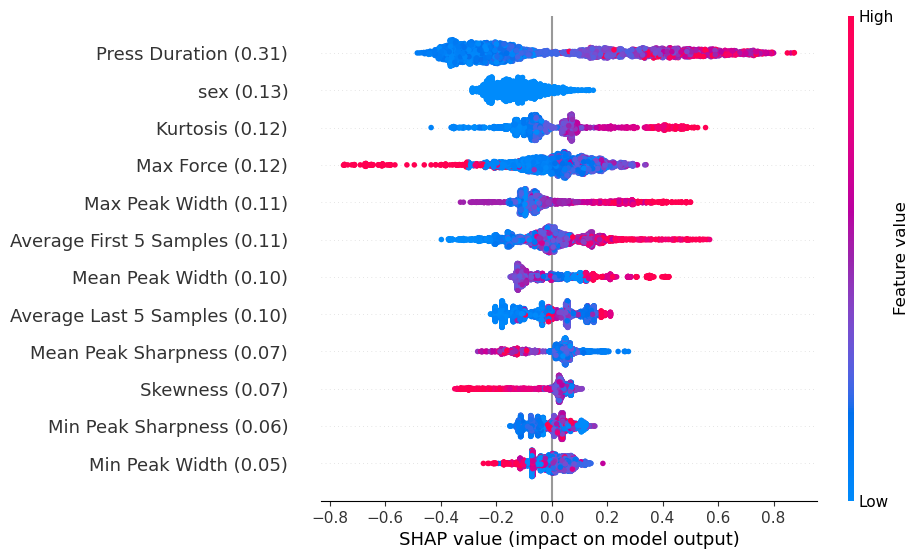

In [92]:
import shap
import numpy as np
import matplotlib.pyplot as plt

shap_values = expl_gb(x_test)
mean_shap = np.abs(shap_values.values).mean(axis=0)

shap_values.feature_names = [
    f"{feature_name_map.get(name, name)} ({mean_shap[i]:.2f})"
    for i, name in enumerate(x_test.columns)
]

plt.figure(figsize=(8, 6))
shap.plots.beeswarm(shap_values, max_display=30, show=False)

fig = plt.gcf()
fig.savefig(f"{figure_path}/shap_plot_GB.png", dpi=300, bbox_inches="tight")
plt.show()

In [18]:
import numpy as np
import pandas as pd
from sklearn.metrics import roc_auc_score

# --- Baseline ---
baseline_auc = roc_auc_score(y_test, gb.predict_proba(x_test)[:, 1])

# Working copy
X_perm = x_test.copy()

# Remaining features
remaining_features = ML_feature_names.copy()

# Store results
sequential_results = []

# Add baseline row
sequential_results.append({
    'Step': 0,
    'Feature Removed': 'BASELINE',
    'AUC': baseline_auc,
    'Marginal AUC Drop': 0.0,
    'Cumulative AUC Drop': 0.0
})

current_auc = baseline_auc

print(f"Baseline AUC: {baseline_auc:.6f}")

# --- Sequential permutation elimination ---
step = 1

while len(remaining_features) > 0:

    feature_drops = []

    # Evaluate each remaining feature
    for feature in remaining_features:

        X_temp = X_perm.copy()

        # Temporarily permute feature
        X_temp[feature] = np.random.permutation(
            X_temp[feature].values
        )

        perm_auc = roc_auc_score(
            y_test,
            gb.predict_proba(X_temp)[:, 1]
        )

        auc_drop = current_auc - perm_auc

        feature_drops.append({
            'Feature': feature,
            'Permuted AUC': perm_auc,
            'AUC Drop': auc_drop
        })

    feature_drops_df = pd.DataFrame(feature_drops)

    # Select feature with largest drop
    worst_row = feature_drops_df.sort_values(
        'AUC Drop',
        ascending=False
    ).iloc[0]

    selected_feature = worst_row['Feature']

    # Permanently permute selected feature
    X_perm[selected_feature] = np.random.permutation(
        X_perm[selected_feature].values
    )

    # Recompute current AUC
    current_auc = roc_auc_score(
        y_test,
        gb.predict_proba(X_perm)[:, 1]
    )

    cumulative_drop = baseline_auc - current_auc

    sequential_results.append({
        'Step': step,
        'Feature Removed': selected_feature,
        'AUC': current_auc,
        'Marginal AUC Drop': worst_row['AUC Drop'],
        'Cumulative AUC Drop': cumulative_drop
    })

    print(
        f"Step {step:2d} | "
        f"Removed: {selected_feature:30s} | "
        f"AUC: {current_auc:.6f} | "
        f"Marginal Drop: {worst_row['AUC Drop']:.6f}"
    )

    remaining_features.remove(selected_feature)
    step += 1

# --- Final dataframe ---
sequential_auc_df = pd.DataFrame(sequential_results)

# Optional pretty feature names
sequential_auc_df['Feature Removed'] = (
    sequential_auc_df['Feature Removed']
    .map(feature_name_map)
    .fillna(sequential_auc_df['Feature Removed'])
)

display(sequential_auc_df)

Baseline AUC: 0.640269
Step  1 | Removed: total_press_duration           | AUC: 0.579169 | Marginal Drop: 0.041310
Step  2 | Removed: pk_widths_max                  | AUC: 0.560724 | Marginal Drop: 0.021099
Step  3 | Removed: pk_widths_mean                 | AUC: 0.541697 | Marginal Drop: 0.014173
Step  4 | Removed: avg_last_5                     | AUC: 0.530448 | Marginal Drop: 0.016053
Step  5 | Removed: pk_widths_min                  | AUC: 0.525392 | Marginal Drop: 0.011937
Step  6 | Removed: avg_first_5                    | AUC: 0.514822 | Marginal Drop: 0.010800
Step  7 | Removed: kurtosis                       | AUC: 0.497664 | Marginal Drop: 0.014669
Step  8 | Removed: max_force                      | AUC: 0.491818 | Marginal Drop: 0.008286
Step  9 | Removed: pk_sharp_min                   | AUC: 0.491327 | Marginal Drop: 0.004251
Step 10 | Removed: skewness                       | AUC: 0.483453 | Marginal Drop: 0.008862
Step 11 | Removed: pk_sharp_mean                  | AUC: 

,Step,Feature Removed,AUC,Marginal AUC Drop,Cumulative AUC Drop
0,0,BASELINE,0.640269,0.000000,0.000000
1,1,Press Duration,0.579169,0.041310,0.061100
2,2,Max Peak Width,0.560724,0.021099,0.079545
3,3,Mean Peak Width,0.541697,0.014173,0.098572
4,4,Average Last 5 Samples,0.530448,0.016053,0.109821
5,5,Min Peak Width,0.525392,0.011937,0.114877
6,6,Average First 5 Samples,0.514822,0.010800,0.125447
7,7,Kurtosis,0.497664,0.014669,0.142604
8,8,Max Force,0.491818,0.008286,0.148451
9,9,Min Peak Sharpness,0.491327,0.004251,0.148942


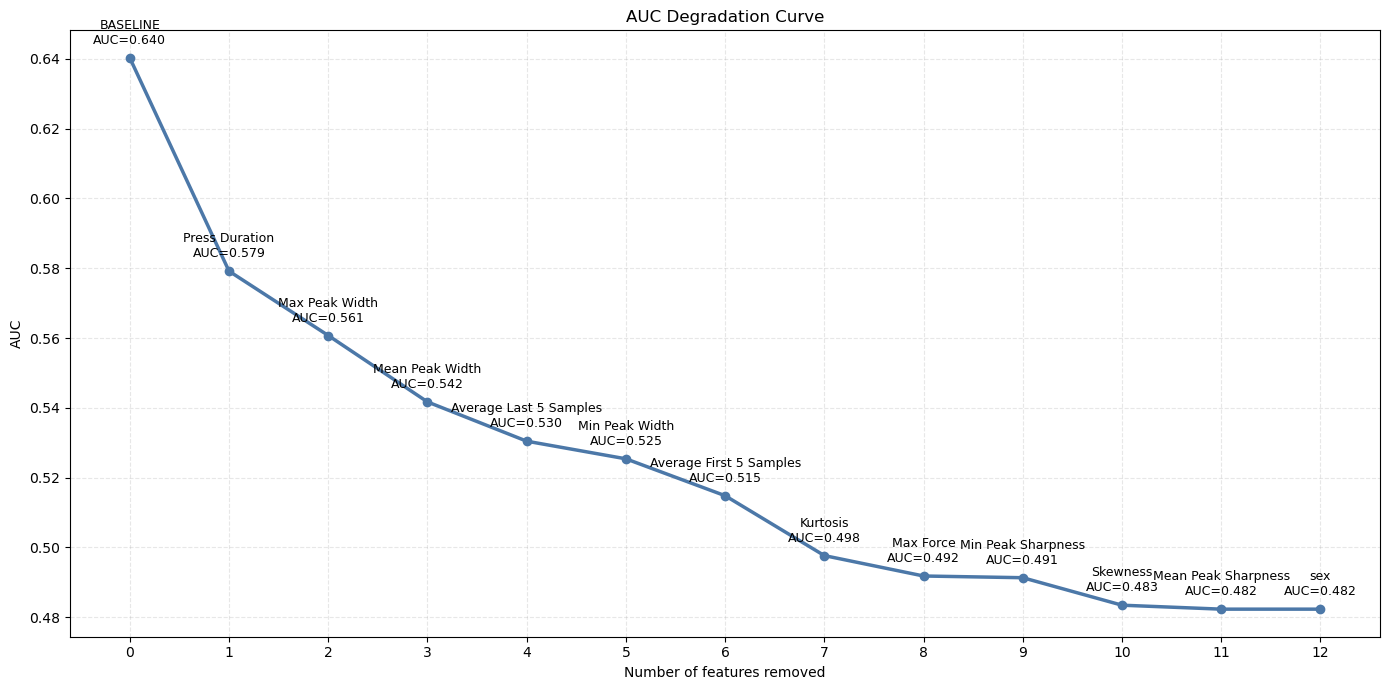

In [20]:
# Line plot of sequential AUC degradation

plt.figure(figsize=(14, 7))

plt.plot(
    sequential_auc_df['Step'],
    sequential_auc_df['AUC'],
    marker='o',
    linewidth=2.5,
    color='#4C78A8'
)

# Annotate AUC values
for _, row in sequential_auc_df.iterrows():

    label = (
        f"{row['Feature Removed']}\n"
        f"AUC={row['AUC']:.3f}"
    )

    plt.annotate(
        label,
        (row['Step'], row['AUC']),
        textcoords='offset points',
        xytext=(0, 10),
        ha='center',
        fontsize=9
    )

plt.xticks(sequential_auc_df['Step'])

plt.xlabel('Number of features removed')
plt.ylabel('AUC')

plt.title('AUC Degradation Curve')

plt.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

# Test dataset

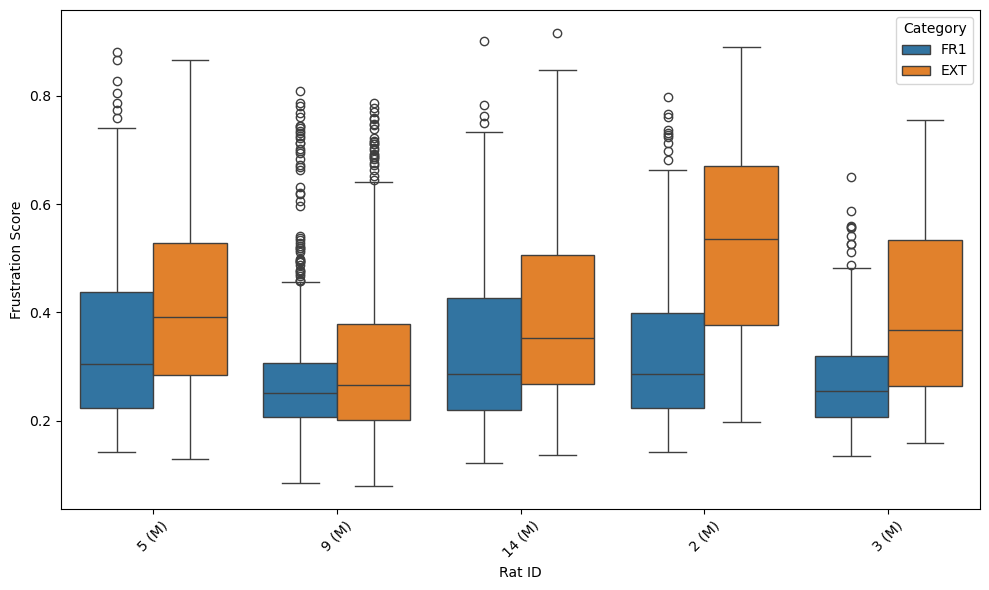

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
df_ML2 = df_ML_test.copy()
df_ML2['id2'] = [i if i<1000 else i-1000 for i in df_ML2['id']]
# combine with sex
df_ML2['id2'] = df_ML2.apply(lambda row: f"{row['id2']} ({'M' if row['sex'] ==1 else 'F'})", axis=1)
sns.boxplot(
    data=df_ML2,
    x='id2',          # group by rat ID
    y='gb_prob',     # probability values
    hue='category'   # FR1 vs EXT
)

plt.xlabel('Rat ID')
plt.ylabel('Frustration Score')
plt.legend(title='Category')
plt.xticks(rotation=45)

plt.tight_layout()

fig = plt.gcf()
fig.savefig(f"{figure_path}/boxplot_holdout.png", dpi=300, bbox_inches="tight")
plt.show()

In [56]:
import pandas as pd
import numpy as np

def aggregate_prob_by_chunk(
    df,
    chunk_size,
    id_col='id',
    label_col='label',
    index_col='index',
    prob_col='gb_prob'
):
    """
    Aggregate gb_prob by mean within fixed-size chunks.

    Chunking is performed:
    - separately within each (id, label)
    - after sorting by index
    - residual rows that do not fill a complete chunk are ignored

    Returns
    -------
    pd.DataFrame
    """

    results = []

    # Sort first
    df_sorted = df.sort_values([id_col, label_col, index_col]).copy()

    # Group by id and label
    for (subject_id, label), group in df_sorted.groupby([id_col, label_col]):

        group = group.reset_index(drop=True)

        # Number of full chunks
        n_full_chunks = len(group) // chunk_size

        # Ignore residual rows
        usable_rows = n_full_chunks * chunk_size

        if usable_rows == 0:
            continue

        group = group.iloc[:usable_rows].copy()

        # Assign chunk ids
        group['chunk_id'] = (
            np.arange(len(group)) // chunk_size
        )

        # Aggregate
        agg = (
            group.groupby('chunk_id')
            .agg(
                id=(id_col, 'first'),
                label=(label_col, 'first'),
                start_index=(index_col, 'min'),
                end_index=(index_col, 'max'),
                gb_prob_mean=(prob_col, 'mean')
            )
            .reset_index(drop=True)
        )

        results.append(agg)

    return pd.concat(results, ignore_index=True)

In [35]:
chunk_sizes = range(1, 101, 1)
results = []
for chunk_size in tqdm(chunk_sizes, desc="Evaluating chunk sizes"):
    chunked_df = aggregate_prob_by_chunk(
        df_ML_test,
        chunk_size=chunk_size,
        id_col='id',
        label_col='label',
        index_col='index',
        prob_col='gb_prob'
    )

    metrics = calc_metrics(
        chunked_df['label'],
        chunked_df['gb_prob_mean']
    )

    results.append((chunk_size, metrics['auc']))
chunk_results_df = pd.DataFrame(results, columns=['Chunk Size', 'AUC'])
display(chunk_results_df)

Evaluating chunk sizes: 100%|██████████| 100/100 [00:48<00:00,  2.05it/s]


,Chunk Size,AUC
0,1,0.640
1,2,0.667
2,3,0.685
3,4,0.698
4,5,0.713
...,...,...
95,96,0.800
96,97,0.791
97,98,0.800
98,99,0.814


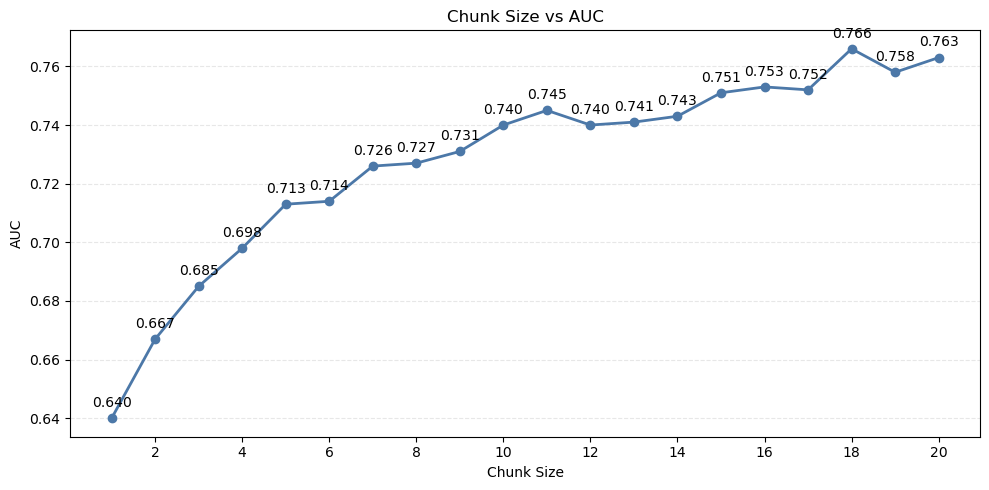

In [100]:
# line plot of chunk size vs AUC
from matplotlib.ticker import MultipleLocator


chunk_results_df2 = chunk_results_df.copy()
chunk_results_df2 = chunk_results_df2[chunk_results_df2['Chunk Size'] <= 20]

plt.figure(figsize=(10, 5))
plt.plot(
    chunk_results_df2['Chunk Size'],
    chunk_results_df2['AUC'],
    marker='o',
    linewidth=2,
    color='#4C78A8'
 )

for chunk_size, auc in zip(chunk_results_df2['Chunk Size'], chunk_results_df2['AUC']):
    plt.annotate(
        f'{auc:.3f}',
        (chunk_size, auc),
        textcoords='offset points',
        xytext=(0, 8),
        ha='center'
    )
ax = plt.gca() 
ax.xaxis.set_major_locator(MultipleLocator(2))
plt.xlabel('Chunk Size')
plt.ylabel('AUC')
plt.title('Chunk Size vs AUC')
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

# Inference

In [43]:
with open(f'{output_base}/df_app_ML.pkl', 'rb') as f:
    df_app_ML = pickle.load(f)

In [44]:
x_app = df_app_ML.loc[:, ML_feature_names]
y_pred = gb.predict_proba(x_app)[:, 1]
df_app_ML['frustration_probability'] = y_pred

In [80]:
subject_ids = [5,9,14]
df_single_app = df_app_ML[df_app_ML['id'].isin(subject_ids)].copy().reset_index(drop=True)
df_single_app['group'] = "PR"

df_single_test = df_ML_test[df_ML_test['id'].isin(subject_ids)].copy().reset_index(drop=True).rename(columns={'gb_prob': 'frustration_probability'})
df_single_test['group'] = df_single_test['label'].map({0: 'FR1', 1: 'EXT'})

df_single_merged = pd.concat([
    df_single_test[['id','frustration_probability', 'group']], 
    df_single_app[['id','frustration_probability', 'group']]], 
    ignore_index=True)

df_single_merged['index'] = df_single_merged.groupby(['id', 'group']).cumcount() + 1



In [82]:
# rolling average
window_size = 10

df_single_rolling = df_single_merged.sort_values(['id', 'group', 'index']).copy()
df_single_rolling['frustration_probability'] = (
    df_single_rolling.groupby(['id', 'group'])['frustration_probability']
    .transform(lambda values: values.rolling(window=window_size, min_periods=window_size).mean())
)

df_single_rolling = df_single_rolling.dropna(subset=['frustration_probability']).reset_index(drop=True)
df_single_rolling['rolling_index'] = df_single_rolling.groupby(['id', 'group']).cumcount() + 1

df_single_rolling


,id,frustration_probability,group,index,rolling_index
0,5,0.322157,EXT,10,1
1,5,0.310529,EXT,11,2
2,5,0.299010,EXT,12,3
3,5,0.292306,EXT,13,4
4,5,0.327382,EXT,14,5
...,...,...,...,...,...
2481,14,0.517456,PR,37,28
2482,14,0.572571,PR,38,29
2483,14,0.611492,PR,39,30
2484,14,0.645522,PR,40,31


In [90]:
def make_line_plot(df, subject_id):
    df2 = df[df['id'] == subject_id].copy()
    df3 = df2[df2['rolling_index'] <= 30].copy()
    plt.figure(figsize=(12, 6))
    sns.lineplot(
        data=df3,
        x='rolling_index',
        y='frustration_probability',
        hue='group',
        marker='o'
    )
    plt.title(f'Rat {subject_id}')
    plt.xlabel('Bar Presses')
    plt.ylabel('Rolling Frustration Score')
    plt.legend(title='Group', loc='upper right')
    plt.tight_layout()
    plt.show()

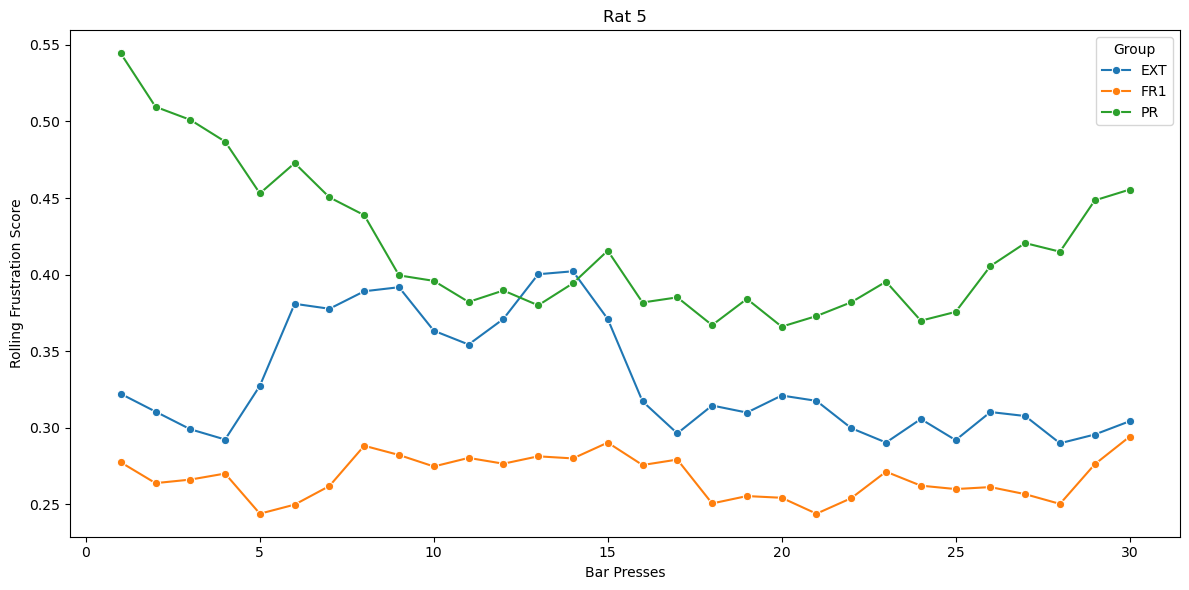

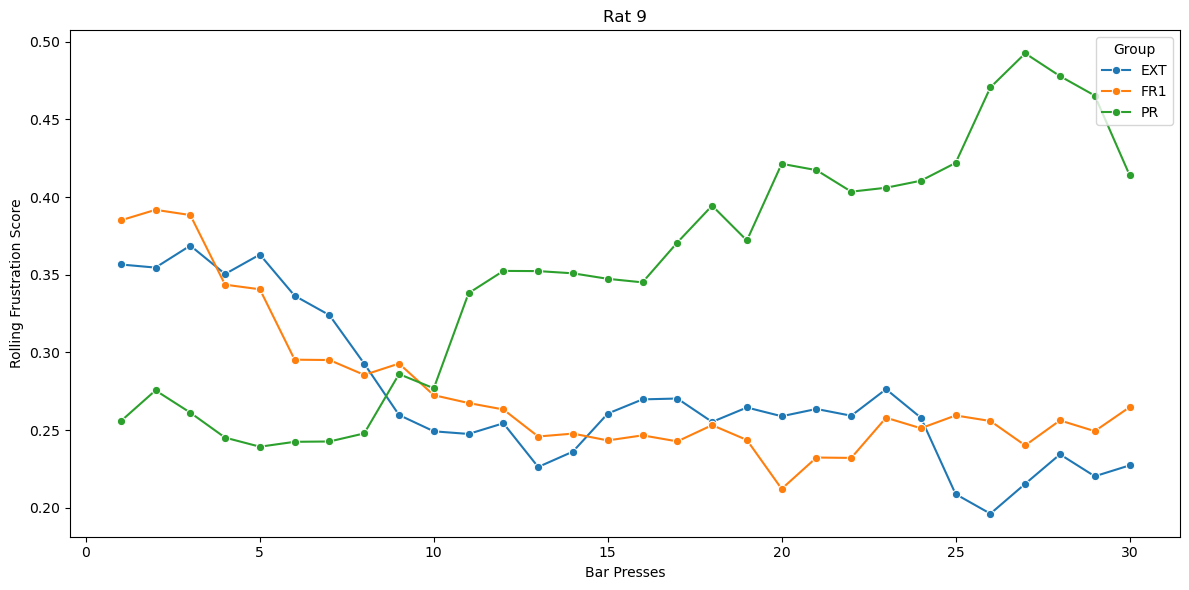

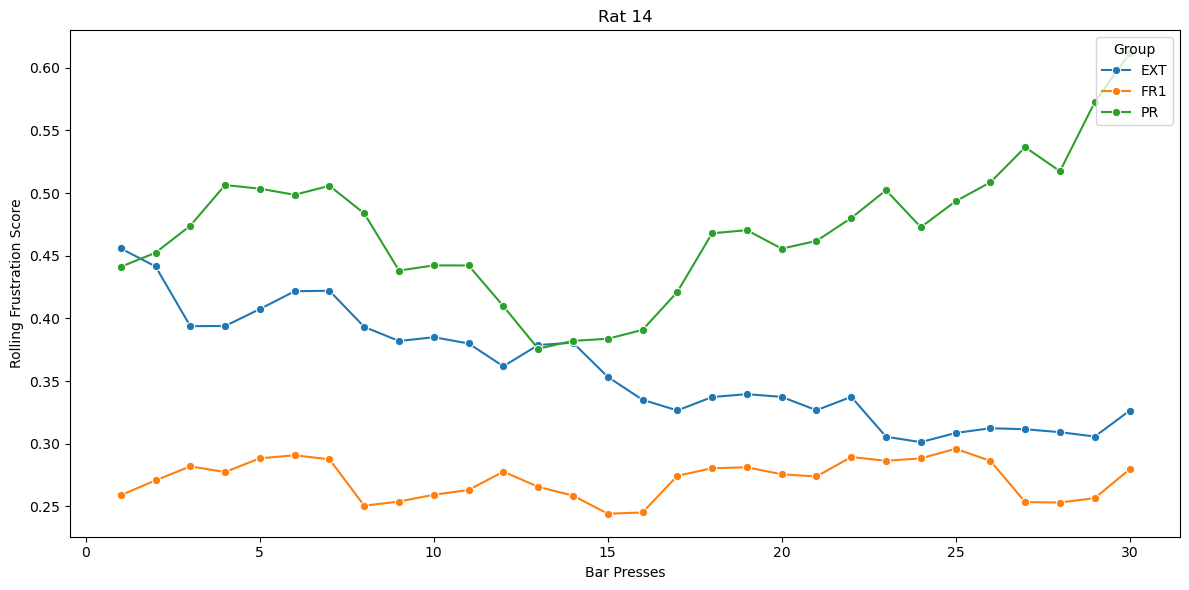

In [91]:
make_line_plot(df_single_rolling, subject_id=5)
make_line_plot(df_single_rolling, subject_id=9)
make_line_plot(df_single_rolling, subject_id=14)

# GRU

In [38]:
from modules.nn_models import GRUModel
from modules.nn_train import dataframe_to_tensors
import torch

gru = GRUModel(input_size=1, hidden_size=256, num_layers=4, feature_size=0)

# load output/gru_models/vgysgbiu/best_model.pt
gru.load_state_dict(torch.load(f"output/gru_models/vgysgbiu/best_model.pt"))


device = "cpu"
nn_test = df_ML_test[['label', 'data']]
nn_test_x, nn_test_y, nn_test_lengths = dataframe_to_tensors(nn_test, device=device)
gru.eval()
with torch.no_grad():
    y_pred_tensor = gru(nn_test_x, nn_test_lengths)
    y_pred = y_pred_tensor.squeeze().numpy()
    # sigmoid to convert logits to probabilities
    y_pred = 1 / (1 + np.exp(-y_pred)) 

df_ML_test["gru_prob"] = y_pred[:,1]
gru_metrics = calc_metrics(y_test, y_pred[:,1])
print(gru_metrics)

{'threshold': 0.38, 'f1_score': 0.578, 'recall': 0.909, 'precision': 0.423, 'auc': 0.651}
